# Benchmarking / validation

Here's a place to compare with Kasturi's implementations.

In [1]:
import immunowave as iw
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt

## Define state and model classes

### Model 4

$$
\begin{align}
\frac{\partial{A}}{\partial t} &= \nabla^2 A + A(A-\theta)(1-A) + \eta B\\
\frac{\partial{B}}{\partial t} &= \xi \nabla^2 B + \lambda B(1-B) -\mu AB
\end{align}
$$

In [2]:
class State4(iw.State):
    A: iw.ScalarField
    B: iw.ScalarField

In [3]:
class Model4(iw.Model):
    θ: float
    η: float
    ξ: float
    λ: float
    μ: float

    def __call__(self, t, state, args=None):
        # unpack field variables
        A, B = state.A, state.B
        # unpack parameters
        θ, η, ξ, λ, μ = self.θ, self.η, self.ξ, self.λ, self.μ
        # define PDE
        dAdt = A.laplacian(bc="neumann") + A * (A - θ) * (1 - A) + η * B
        dBdt = ξ * B.laplacian(bc="neumann") + λ * B * (1 - B) - μ * A * B
        return State4(dAdt, dBdt)

### Model 5

$$
\begin{align*}
\partial_t A &= \nabla^2 A + A (A - \theta) (1 - A) + \eta B - \rho R \\
\partial_t B &= \xi \nabla^2 B + \lambda B (1-B) - \mu A B\\
\partial_t R &= \epsilon (A - R)
\end{align*}
$$

In [4]:
class State5(iw.State):
    A: iw.ScalarField
    B: iw.ScalarField
    R: iw.ScalarField

In [5]:
class Model5(iw.Model):
    θ: float
    η: float
    ρ: float
    ε: float
    ξ: float
    λ: float
    μ: float

    def __call__(self, t, state, args=None):
        # unpack field variables
        A, B, R = state.A, state.B, state.R
        # unpack parameters
        θ, η, ρ, ε, ξ, λ, μ = self.θ, self.η, self.ρ, self.ε, self.ξ, self.λ, self.μ
        # define PDE
        dAdt = A.laplacian(bc="neumann") + A * (A - θ) * (1 - A) + η * B - ρ * R
        dBdt = ξ * B.laplacian(bc="neumann") + λ * B * (1 - B) - μ * A * B
        dRdt = ε * (A - R)

        return State5(dAdt, dBdt, dRdt)

## Define spatial domain and time points

In [6]:
L = 20
n = 1000

shape = (n,)
lb = [0.0]
h = L / (n - 1)

t = np.arange(0.0, 31, 1)

## Instantiate, solve, and plot both models

For both models, the B field is initialized with a Gaussian, and the other fields are initialized to zero.

In [7]:
def gaussian_init(x):
    return jnp.exp(-((x - L / 2) ** 2) / (2 * 0.1**2))

Args and kwargs for the `solve` method

In [8]:
args = t[0], t[-1]
kwargs = dict(t=t, dt0=1e-4, max_steps=1000000, atol=1e-8, rtol=1e-8)

Colormap for time in plots

In [9]:
cmap = plt.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=t[0], vmax=t[-1]), cmap=plt.cm.viridis
)

In [10]:
models = (
    Model4(θ=0.1, η=10.0, ξ=0.1, λ=0.9, μ=0.1),
    Model5(θ=0.1, η=10.0, ρ=0.5, ε=0.1, ξ=0.1, λ=0.9, μ=0.1),
)
states = (
    State4(
        A=iw.ScalarField(shape, lb, h, 0),
        B=iw.ScalarField(shape, lb, h, fn=gaussian_init),
    ),
    State5(
        A=iw.ScalarField(shape, lb, h, 0),
        B=iw.ScalarField(shape, lb, h, fn=gaussian_init),
        R=iw.ScalarField(shape, lb, h, 0),
    ),
)

Model4
------


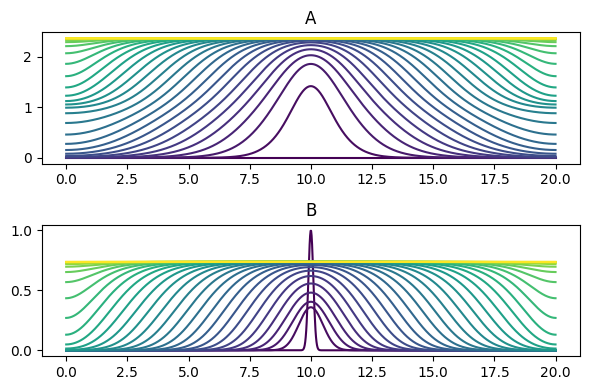

Model5
------


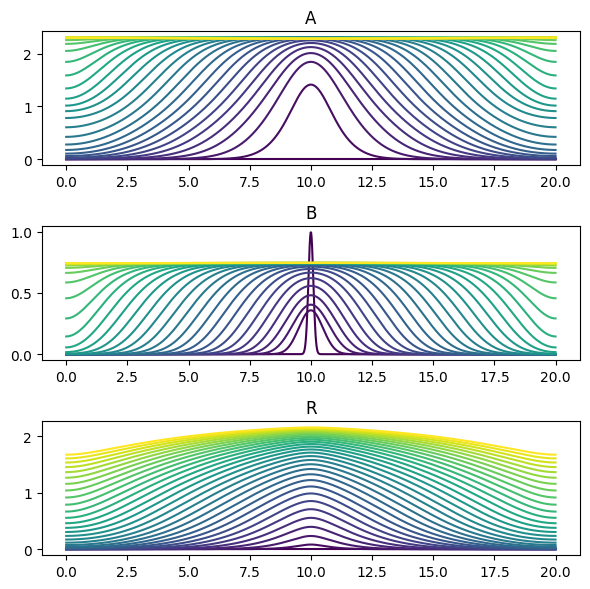

In [11]:
for model, state in zip(models, states):
    print(model.__class__.__name__ + "\n------")
    solution = iw.solve(model, state, *args, **kwargs)
    axes = None
    for i, ti in enumerate(t):
        axes = solution.ys.plot(axes=axes, time_idx=i, color=cmap.to_rgba(ti))
    plt.show()